In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# Paths
final_signals = "replicate_atlas"

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/25886

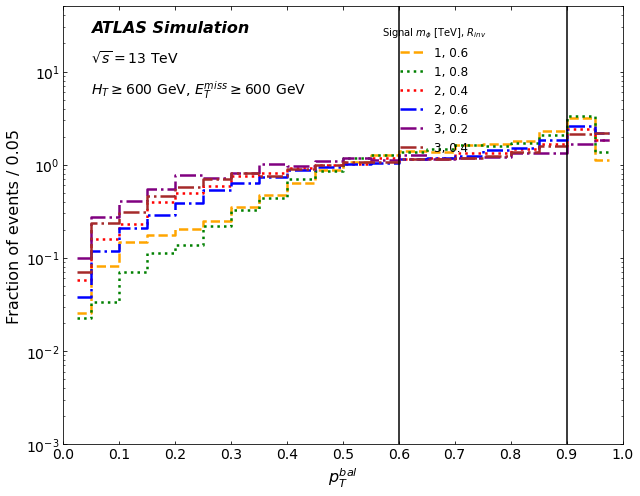

/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/2588607658.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_final = pd.read_csv(path_final, delim_whitespace=True)
/tmp/ipykernel_2103223/25886

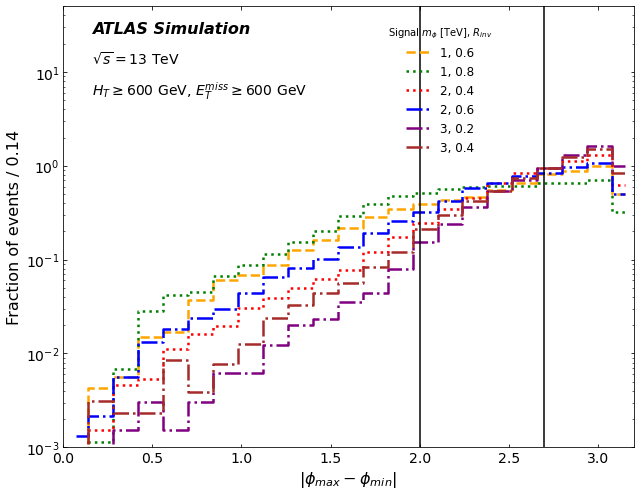

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 1. Define paths and modes
# final_signals = "your/path/here" 
target_modes = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

styles = {
    '1000_6': ('orange', '--'),      # 1 TeV, 0.6
    '1000_8': ('green', ':'),        # 1 TeV, 0.8
    '2000_4': ('red', ':'),          # 2 TeV, 0.4
    '2000_6': ('blue', '-.'),        # 2 TeV, 0.6
    '3000_2': ('purple', '-.'),      # 3 TeV, 0.2
    '3000_4': ('brown', '-.')        # 3 TeV, 0.4
}

# Define which variables to plot and their specific configurations
variables_to_plot = {
    'pt_balance': {
        'bins': np.linspace(0, 1, 21), # 0.05 width
        'xlabel': r'$p_T^{bal}$',
        'ylabel': 'Fraction of events / 0.05',
        'xlim': (0, 1),
        'vlines': [0.6, 0.9],
        'xticks': np.arange(0, 1.1, 0.1)
    },
    'delta_phi_j1j2': {
        'bins': np.linspace(0, 3.22, 24), # ~0.14 width to match ATLAS image
        'xlabel': r'$|\phi_{max} - \phi_{min}|$',
        'ylabel': 'Fraction of events / 0.14',
        'xlim': (0, 3.2),
        'vlines': [2.0, 2.7],
        'xticks': np.arange(0, 3.5, 0.5)
    }
}

for var_name, config in variables_to_plot.items():
    plt.figure(figsize=(9, 7))
    ax = plt.gca()

    for mode in target_modes:
        mass, rinv = mode.split('_')
        file_name_final = f"{mass}_{rinv}_events_markIX.txt"
        path_final = os.path.join(final_signals, file_name_final)

        try:
            df_final = pd.read_csv(path_final, delim_whitespace=True)
            
            # SR Cuts
            df_screened = df_final[
                (df_final['ht'] >= 600) & 
                (df_final['met'] >= 600)
            ]
            
            if df_screened.empty:
                continue

            data_to_plot = df_screened[var_name]

            # Calculate Histogram (density=True creates the 'Fraction of events' look)
            counts, edges = np.histogram(data_to_plot, bins=config['bins'], density=True)
            # Normalize to unit area if necessary, or keep density for shape comparison
            bin_centers = (edges[:-1] + edges[1:]) / 2

            color, linestyle = styles.get(mode, ('black', '-'))
            label_m = int(mass) // 1000
            display_rinv = float(rinv) / 10 if len(rinv) == 1 else float(rinv)
            label = f"{label_m}, {display_rinv}"

            plt.plot(bin_centers, counts, 
                     drawstyle='steps-mid', 
                     color=color, 
                     linestyle=linestyle, 
                     linewidth=2.5, 
                     label=label)

        except Exception as e:
            print(f"Error processing {mode}: {e}")

    # --- Decoration Logic ---
    # Vertical cut lines (2.0 and 2.7 for deltaphi)
    for vline in config['vlines']:
        plt.axvline(x=vline, color='black', linestyle='-', linewidth=1.5)

    plt.yscale('log')
    plt.ylim(1e-3, 50) 
    plt.xlim(config['xlim'])
    plt.xlabel(config['xlabel'], fontsize=16)
    plt.ylabel(config['ylabel'], fontsize=16)

    # ATLAS Text
    plt.text(0.05, 0.94, 'ATLAS Simulation', transform=ax.transAxes,
             fontsize=16, fontweight='bold', style='italic')
    plt.text(0.05, 0.87, r'$\sqrt{s} = 13$ TeV', transform=ax.transAxes, fontsize=14)
    plt.text(0.05, 0.80, r'$H_T \geq 600$ GeV, $E_T^{miss} \geq 600$ GeV', transform=ax.transAxes, fontsize=14)

    # Legend
    plt.legend(title=r'Signal $m_{\phi}$ [TeV], $R_{inv}$', 
               loc='upper left', bbox_to_anchor=(0.55, 0.98), 
               frameon=False, fontsize=12)

    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)
    plt.xticks(config['xticks'])
    
    plt.tight_layout()
    plt.show()